In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import torch
from nanodrz.model import DiarizeGPT, Config
from nanodrz.data import libritts_test, artificial_diarisation_sample
from nanodrz.utils import visualise_annotation, play

In [3]:
ckpt = torch.load("/home/harry/0006500.pt")
config = Config(**ckpt["config"])
model:DiarizeGPT = DiarizeGPT.from_pretrained(ckpt).cuda()

/home/harry/diarisation/.venv/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:30: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


27.456875


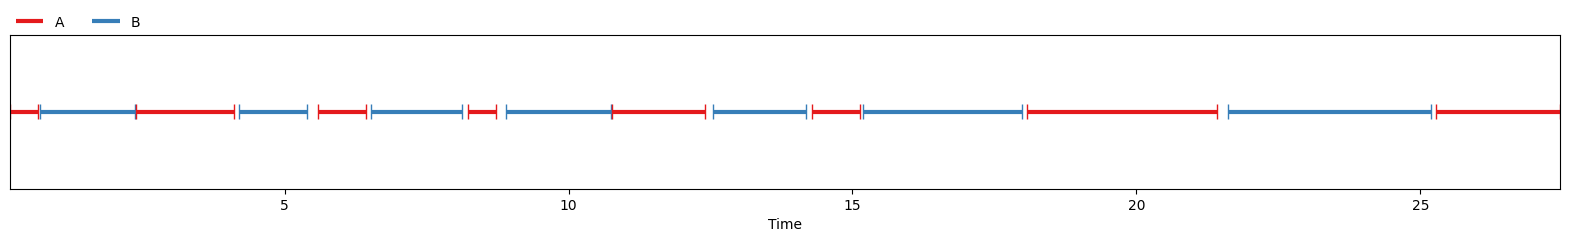

[[0.1665, 0.4979375, 'A'],
 [0.701625, 1.659, 'B'],
 [2.3781875, 1.73, 'A'],
 [4.195374999999999, 1.197125, 'B'],
 [5.58275, 0.855, 'A'],
 [6.5249375, 1.591875, 'B'],
 [8.2263125, 0.4979375, 'A'],
 [8.9055625, 1.839625, 'B'],
 [10.7643125, 1.6339375, 'A'],
 [12.550062500000001, 1.6374375, 'B'],
 [14.280875, 0.855, 'A'],
 [15.18425, 2.794, 'B'],
 [18.07825, 3.333375, 'A'],
 [21.60875, 3.5783125, 'B'],
 [25.270062499999998, 2.1868125, 'A']]

In [4]:
# Use the same parameters that the model was trained on to generate a sample
audio, labels = artificial_diarisation_sample(libritts_test(), **config.data.model_dump())
print(audio.shape[-1]/16000)
visualise_annotation(labels)
play(audio)
labels

[[0.29880478978157043, 1.13545823097229, 'A'], [1.3745020627975464, 2.868525981903076, 'B'], [9.621514320373535, 12.01195240020752, 'B'], [7.88844633102417, 9.681275367736816, 'A'], [2.9880478382110596, 4.422310829162598, 'A'], [17.509960174560547, 19.123506546020508, 'B'], [4.54183292388916, 7.768924713134766, 'A'], [12.191235542297363, 14.163347244262695, 'B'], [15.597610473632812, 17.569721221923828, 'A'], [17.749004364013672, 19.482072830200195, 'B']]


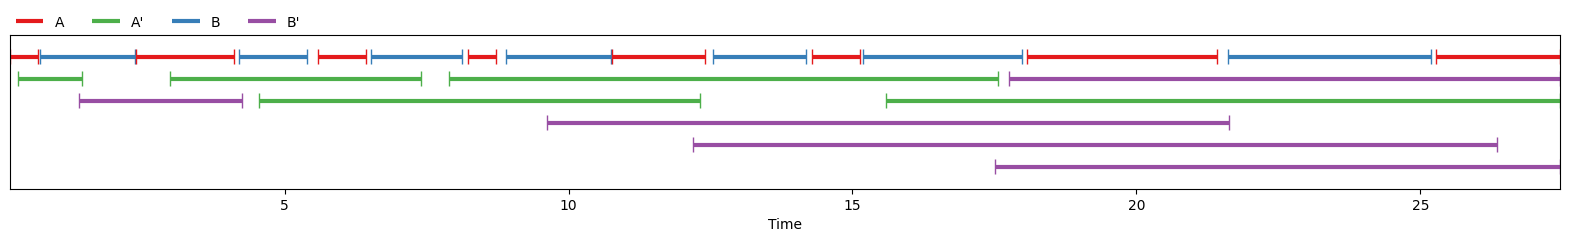

In [6]:
nlabels = model.generate(audio.cuda(), temperature=.3)
print(nlabels)
for l in nlabels:
    l[2] = l[2]+ "'"
visualise_annotation(labels+nlabels)